In [9]:
#Libraries
#Importando bibliotecas de suporte
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#importando preprocessamentos
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#importando mensuradores
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#importando modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#importando otimizacao
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Parte 1 - Analise exploratoria 

In [10]:
#carregando o dataset — arquivo txt separado por tabs, sem header
colunas = ['area', 'perimetro', 'compacidade', 'comprimento_nucleo',
           'largura_nucleo', 'coef_assimetria', 'comprimento_sulco', 'variedade']

df = pd.read_csv('seeds.txt', sep='\s+', names=colunas, engine='python')

#mapeando classes numericas para nomes das variedades
df['variedade'] = df['variedade'].map({1: 'Kama', 2: 'Rosa', 3: 'Canadian'})

df.head()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco,variedade
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama


In [11]:
#estrutura do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                210 non-null    float64
 1   perimetro           210 non-null    float64
 2   compacidade         210 non-null    float64
 3   comprimento_nucleo  210 non-null    float64
 4   largura_nucleo      210 non-null    float64
 5   coef_assimetria     210 non-null    float64
 6   comprimento_sulco   210 non-null    float64
 7   variedade           210 non-null    str    
dtypes: float64(7), str(1)
memory usage: 13.3 KB


In [12]:
#estatisticas descritivas
df.describe()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coef_assimetria,comprimento_sulco
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


In [13]:
#checando valores ausentes
df.isnull().sum()

area                  0
perimetro             0
compacidade           0
comprimento_nucleo    0
largura_nucleo        0
coef_assimetria       0
comprimento_sulco     0
variedade             0
dtype: int64

In [14]:
#distribuicao das classes
df['variedade'].value_counts()

variedade
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64

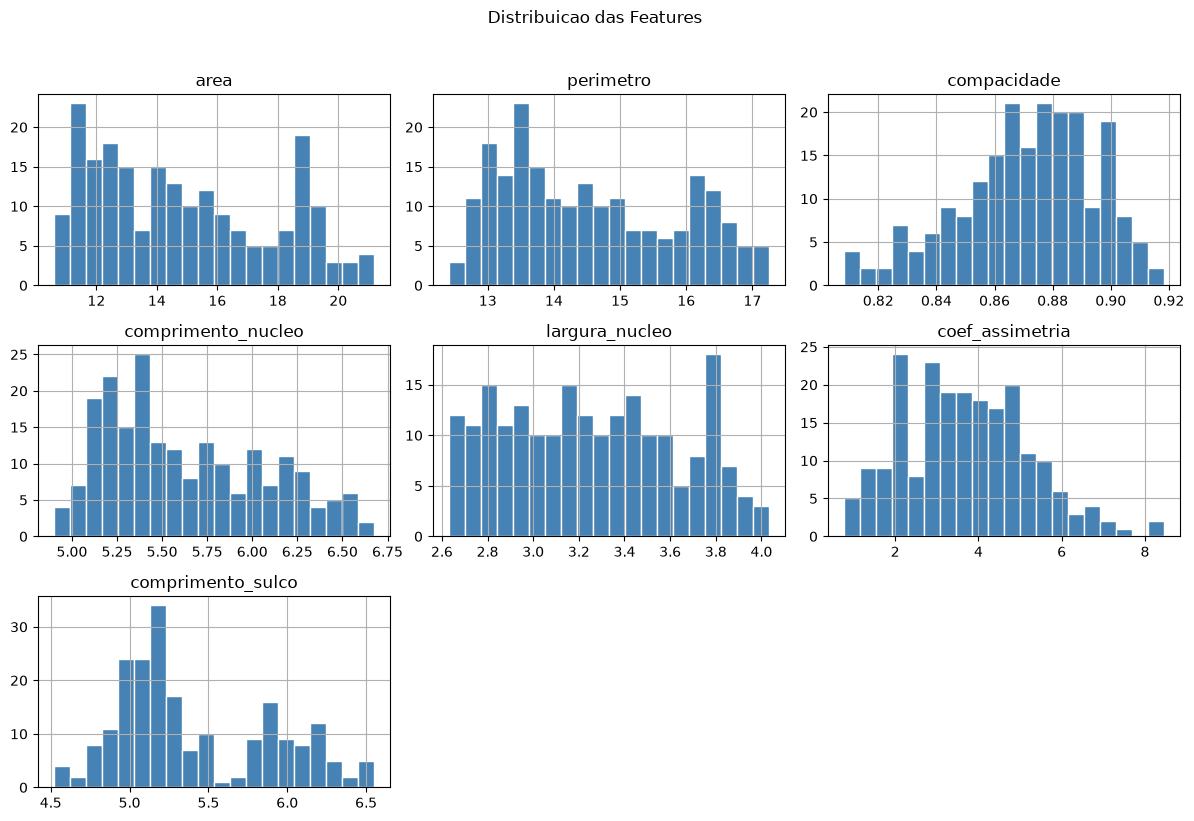

In [15]:
#histogramas das features
features = ['area', 'perimetro', 'compacidade', 'comprimento_nucleo',
            'largura_nucleo', 'coef_assimetria', 'comprimento_sulco']

df[features].hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribuicao das Features', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

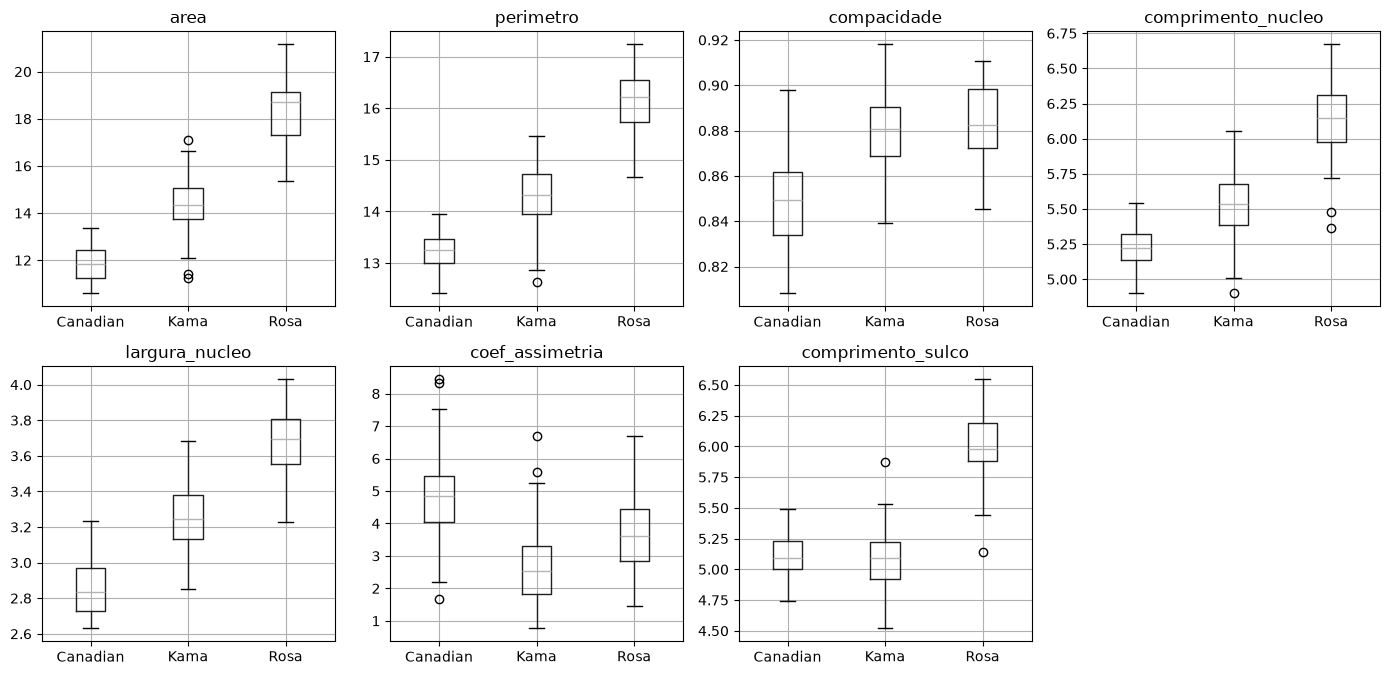

In [16]:
#boxplots por variedade para identificar separabilidade
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.boxplot(column=feature, by='variedade', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('')
plt.tight_layout()
plt.show()

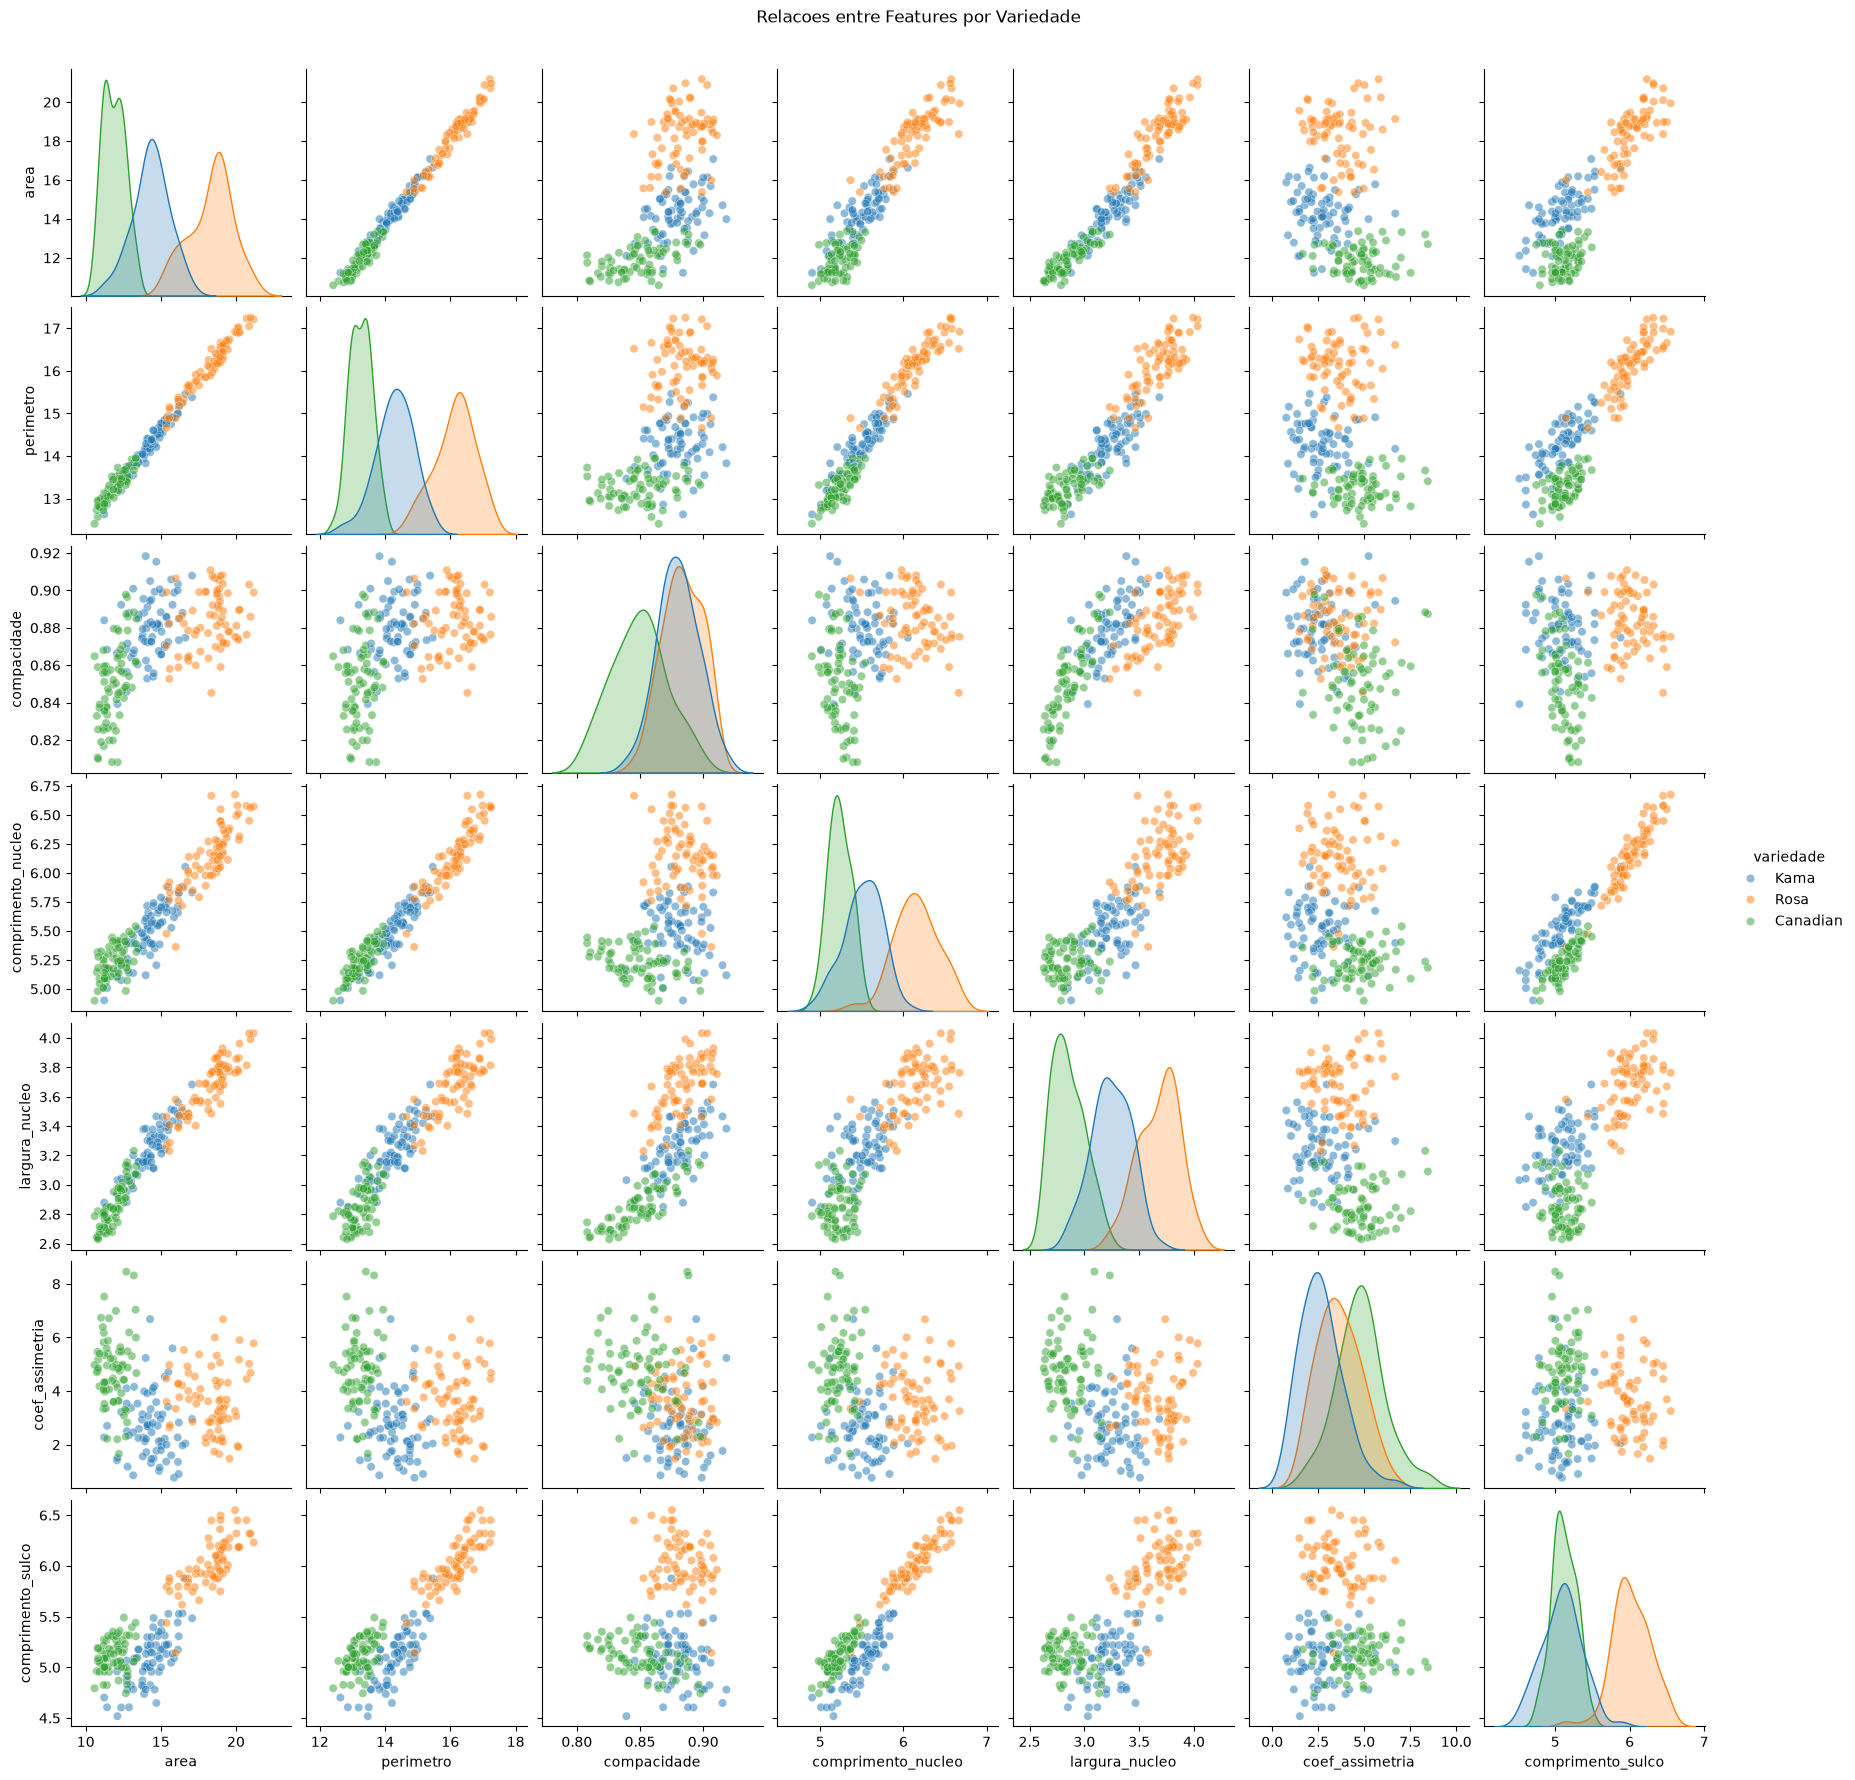

In [17]:
#scatter plot matrix para identificar relacoes entre features
sns.pairplot(df, hue='variedade', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Relacoes entre Features por Variedade', y=1.02)
plt.show()

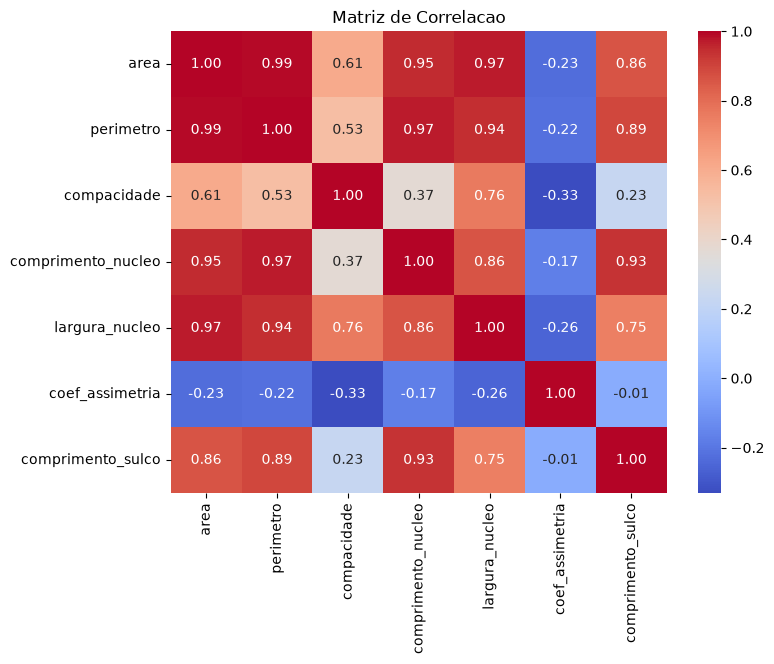

In [18]:
#matriz de correlacao
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlacao')
plt.show()

### Analise Parte 1

O Seeds Dataset é composto por 210 amostras perfeitamente balanceadas: 70 grãos de cada variedade (Kama, Rosa e Canadian). O balanceamento entre classes é uma condição favorável para o treinamento — elimina a necessidade de técnicas de balanceamento como class_weight='balanced' que foram necessárias em datasets anteriores. Não foram encontrados valores ausentes em nenhuma das sete features, o que indica uma base de dados limpa e pronta para uso.
As features com maior amplitude de variação são area (10.59 a 21.18) e coef_assimetria (0.77 a 8.46), enquanto compacidade opera em uma faixa estreita (próxima de 0.88 em média). Os boxplots revelam que Rosa tende a ter grãos maiores em área e perímetro, Canadian concentra os menores valores, e Kama ocupa uma posição intermediária — o que sugere que as features de tamanho devem ter alto poder discriminativo entre as variedades.
A aplicação do StandardScaler foi necessária especialmente para KNN e SVM, que são sensíveis à escala absoluta das features.

# Fase 2 - Preprocessamento

In [19]:
#separando features e alvo
x = df[features]
y = df['variedade']

#separando treino e teste — 70/30 conforme enunciado
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

#escalando dados — KNN e SVM sao sensiveis a escala
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#convertendo de volta para DataFrame para manter nomes das colunas
x_train = pd.DataFrame(x_train, columns=features)
x_test = pd.DataFrame(x_test, columns=features)

print(f'Treino: {x_train.shape[0]} amostras')
print(f'Teste: {x_test.shape[0]} amostras')

Treino: 147 amostras
Teste: 63 amostras


### Analise fase 2 
Todos os cinco modelos performaram bem neste dataset, com acurácias entre 84% e 90% no conjunto de teste, o que já era esperado dado o balanceamento perfeito das classes e a separabilidade das features de morfologia de grãos.
A Regressão Logística liderou com 90.5% de acurácia, seguida por KNN e SVM empatados em 88.9%. Decision Tree alcançou 85.7% e Random Forest 84.1% — um resultado contraintuitivo, já que Random Forest é em geral mais robusto que uma árvore simples. Neste caso específico, o max_depth=3 limitou a capacidade do Random Forest de explorar combinações entre árvores, enquanto a Árvore de Decisão simples com a mesma profundidade capturou os padrões lineares do dataset com menos ruído.
O padrão de erros foi consistente entre os modelos: a maior dificuldade foi distinguir Canadian de Kama — as duas variedades de menor tamanho — enquanto Rosa foi classificada corretamente com precisão e recall de 95% em todos os modelos, sem exceção. Isso confirma visualmente o que os boxplots já sugeriam: Rosa é morfologicamente bem separada das outras duas variedades.

# Fase 3 - Treinamento e Comparacao dos Modelos

In [ ]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train, y_train)
lr_predict = lr.predict(x_test)

print('Logistic Regression')
print(classification_report(y_test, lr_predict))
print(confusion_matrix(y_test, lr_predict))

Logistic Regression
              precision    recall  f1-score   support

    Canadian       0.90      0.90      0.90        21
        Kama       0.86      0.86      0.86        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.90        63
   macro avg       0.90      0.90      0.90        63
weighted avg       0.90      0.90      0.90        63

[[19  2  0]
 [ 2 18  1]
 [ 0  1 20]]


In [21]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
knn_predict = knn.predict(x_test)

print('KNN')
print(classification_report(y_test, knn_predict))
print(confusion_matrix(y_test, knn_predict))

KNN
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63

[[19  2  0]
 [ 3 17  1]
 [ 0  1 20]]


In [22]:
#Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(x_train, y_train)
dt_predict = dt.predict(x_test)

print('Decision Tree')
print(classification_report(y_test, dt_predict))
print(confusion_matrix(y_test, dt_predict))

Decision Tree
              precision    recall  f1-score   support

    Canadian       0.77      0.95      0.85        21
        Kama       0.88      0.67      0.76        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.86        63
   macro avg       0.87      0.86      0.85        63
weighted avg       0.87      0.86      0.85        63

[[20  1  0]
 [ 6 14  1]
 [ 0  1 20]]


Random Forest
              precision    recall  f1-score   support

    Canadian       0.78      0.86      0.82        21
        Kama       0.79      0.71      0.75        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.84      0.84      0.84        63

[[18  3  0]
 [ 5 15  1]
 [ 0  1 20]]


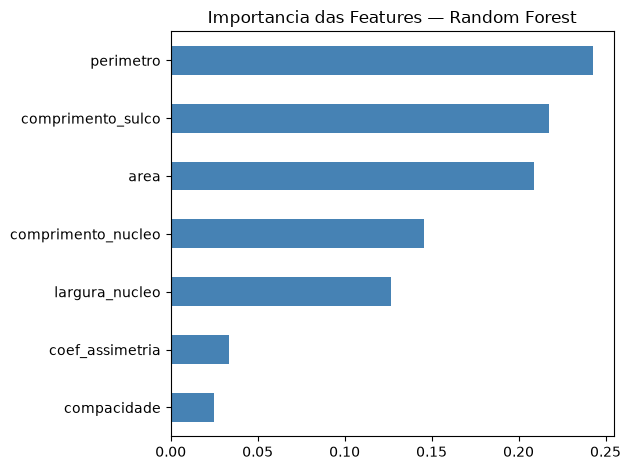

In [23]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(x_train, y_train)
rf_predict = rf.predict(x_test)

print('Random Forest')
print(classification_report(y_test, rf_predict))
print(confusion_matrix(y_test, rf_predict))

#visualizando importancia das features
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Importancia das Features — Random Forest')
plt.tight_layout()
plt.show()

In [24]:
#SVM
svm = SVC(kernel='rbf', random_state=42, C=1.0)
svm.fit(x_train, y_train)
svm_predict = svm.predict(x_test)

print('SVM')
print(classification_report(y_test, svm_predict))
print(confusion_matrix(y_test, svm_predict))

SVM
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63

[[19  2  0]
 [ 3 17  1]
 [ 0  1 20]]


In [25]:
#comparando modelos via cross-validation
models = {
    'Logistic Regression': lr,
    'KNN': knn,
    'Decision Tree': dt,
    'Random Forest': rf,
    'SVM': svm
}

for name, model in models.items():
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring='f1_macro')
    print(f"{name} - Media: {scores.mean():.2f}, Desvio Padrao: {scores.std():.2f}, Minimo: {scores.min():.2f}")

Logistic Regression - Media: 0.95, Desvio Padrao: 0.03, Minimo: 0.90
KNN - Media: 0.94, Desvio Padrao: 0.04, Minimo: 0.89
Decision Tree - Media: 0.94, Desvio Padrao: 0.04, Minimo: 0.89
Random Forest - Media: 0.94, Desvio Padrao: 0.04, Minimo: 0.87
SVM - Media: 0.95, Desvio Padrao: 0.03, Minimo: 0.90


### Analise fase 3
A validação cruzada com 5 folds revelou um dado importante antes mesmo da otimização: Regressão Logística e SVM já apresentavam F1-macro médio de 0.953 no conjunto de treino, bem acima dos 0.938–0.940 dos demais modelos. Isso sinalizou esses dois como os melhores candidatos para otimização.
O Grid Search no SVM testou combinações de kernel (rbf e linear), C (0.1 a 100) e gamma (scale e auto). O melhor resultado encontrado foi C=1, kernel='linear', gamma='scale', com F1-macro de 0.973 na validação cruzada — um ganho real em relação ao modelo base. O kernel linear superou o RBF neste contexto, o que faz sentido: features morfológicas de grãos tendem a ter fronteiras de decisão aproximadamente lineares quando bem escaladas.
O Grid Search no Random Forest encontrou max_depth=5, min_samples_split=2, n_estimators=50 como configuração ótima (F1-macro 0.946), mas o desempenho no conjunto de teste não melhorou em relação ao modelo base — ambos ficaram em 84.1%. Isso indica que o Random Forest atingiu seu teto com este conjunto de features, e que a limitação não é de hiperparâmetros, mas de adequação do algoritmo ao problema.

# Fase 4 - Insights e Conclusões

In [26]:
#Grid Search no SVM — melhor candidato pelo cross-validation
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(x_train, y_train)

print(f'Melhores parametros SVM: {grid_svm.best_params_}')
print(f'Melhor score CV: {grid_svm.best_score_:.2f}')

Melhores parametros SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Melhor score CV: 0.97


In [27]:
#Grid Search no Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(x_train, y_train)

print(f'Melhores parametros RF: {grid_rf.best_params_}')
print(f'Melhor score CV: {grid_rf.best_score_:.2f}')

Melhores parametros RF: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Melhor score CV: 0.95


In [28]:
#avaliando modelos otimizados no conjunto de teste
svm_otimizado = grid_svm.best_estimator_
svm_opt_predict = svm_otimizado.predict(x_test)

print('SVM Otimizado')
print(classification_report(y_test, svm_opt_predict))
print(confusion_matrix(y_test, svm_opt_predict))

SVM Otimizado
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63

[[19  2  0]
 [ 3 17  1]
 [ 0  1 20]]


In [29]:
rf_otimizado = grid_rf.best_estimator_
rf_opt_predict = rf_otimizado.predict(x_test)

print('Random Forest Otimizado')
print(classification_report(y_test, rf_opt_predict))
print(confusion_matrix(y_test, rf_opt_predict))

Random Forest Otimizado
              precision    recall  f1-score   support

    Canadian       0.78      0.86      0.82        21
        Kama       0.79      0.71      0.75        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.84      0.84      0.84        63

[[18  3  0]
 [ 5 15  1]
 [ 0  1 20]]


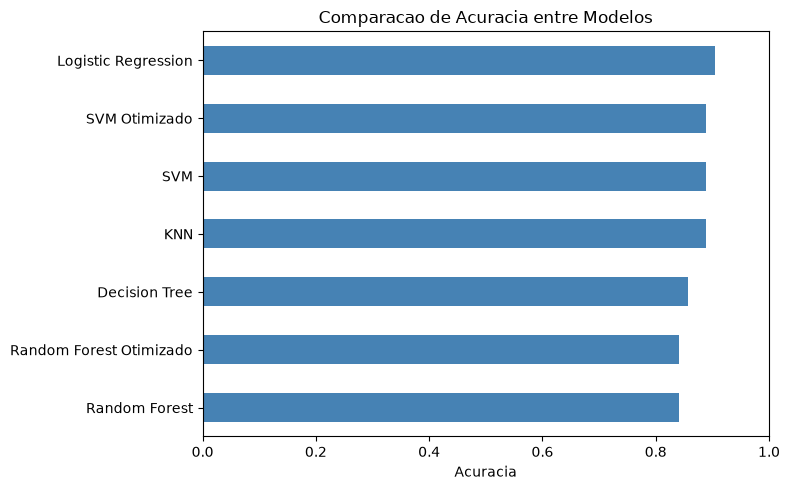

                         Acuracia
Logistic Regression      0.904762
KNN                      0.888889
SVM                      0.888889
SVM Otimizado            0.888889
Decision Tree            0.857143
Random Forest            0.841270
Random Forest Otimizado  0.841270


In [30]:
#tabela comparativa de acuracia no conjunto de teste
from sklearn.metrics import accuracy_score

resultados = {
    'Logistic Regression': accuracy_score(y_test, lr_predict),
    'KNN': accuracy_score(y_test, knn_predict),
    'Decision Tree': accuracy_score(y_test, dt_predict),
    'Random Forest': accuracy_score(y_test, rf_predict),
    'SVM': accuracy_score(y_test, svm_predict),
    'SVM Otimizado': accuracy_score(y_test, svm_opt_predict),
    'Random Forest Otimizado': accuracy_score(y_test, rf_opt_predict)
}

resultados_df = pd.DataFrame.from_dict(resultados, orient='index', columns=['Acuracia'])
resultados_df = resultados_df.sort_values('Acuracia', ascending=True)

resultados_df.plot(kind='barh', figsize=(8, 5), color='steelblue', legend=False)
plt.xlabel('Acuracia')
plt.title('Comparacao de Acuracia entre Modelos')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(resultados_df.sort_values('Acuracia', ascending=False))

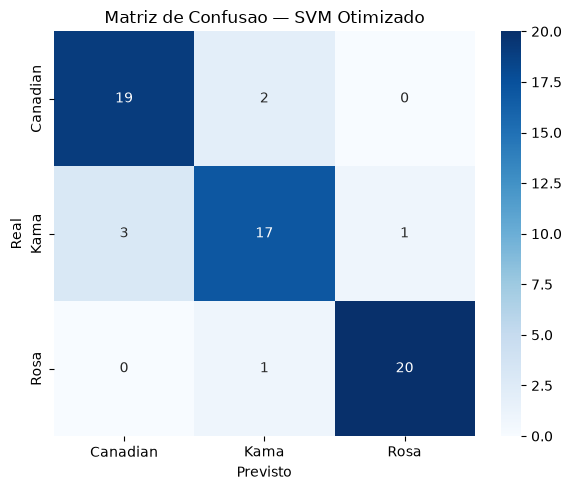

In [31]:
#matriz de confusao do melhor modelo de forma visual
melhor_predict = svm_opt_predict  #ajuste se outro modelo for melhor
classes = ['Canadian', 'Kama', 'Rosa']

cm = confusion_matrix(y_test, melhor_predict, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusao — SVM Otimizado')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

### Analise fase 4 

Melhor modelo para a cooperativa: Regressão Logística (90.5%), seguida de perto pelo SVM otimizado (89%). A escolha entre os dois depende do contexto operacional: Regressão Logística é mais interpretável e mais rápida de treinar com dados novos — vantagem relevante em ambientes com recursos computacionais limitados, como cooperativas de pequeno porte.
O tipo de erro mais custoso neste contexto é confundir Canadian com Kama (o erro mais frequente em todos os modelos): ambas são variedades de menor tamanho, e uma classificação errada pode comprometer lotes mistos que seriam vendidos como produto homogêneo. Rosa foi classificada com 95% de precisão e recall em todos os modelos — o tamanho maior e formato mais distinto da variedade a torna praticamente inequívoca.
As features mais discriminativas, segundo o Random Forest, são perímetro (24.3%), comprimento do sulco (21.8%) e área (20.9%). O coeficiente de assimetria e a compacidade tiveram importância marginal (3.4% e 2.5% respectivamente) — o que sugere que, em uma versão simplificada do sistema para campo, as três features de tamanho já capturariam a maior parte do poder preditivo sem necessidade das features de forma.
Conclusão geral: um modelo de classificação automática de grãos baseado em medições físicas é viável com alta acurácia mesmo com algoritmos simples. A automação desse processo eliminaria a variabilidade humana na classificação manual e permitiria triagem em escala — o objetivo central do enunciado.